In [ ]:
import glob
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.stats.api as sms
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore runtime warnings from scipy and set a clean chart style
warnings.filterwarnings('ignore', category=RuntimeWarning)
sns.set_theme(style="whitegrid")

# 1. Load and concatenate 10 quarters(Q1 2024 - Q2 2026)
file_list = sorted(glob.glob("indego-trips-*.csv"))
df = pd.concat([pd.read_csv(f, low_memory=False) for f in file_list], ignore_index=True)

# 2. Parse timestamps
df['start_time'] = pd.to_datetime(df['start_time'])
df['year_quarter'] = df['start_time'].dt.to_period('Q')

# 3. Clean records: enforce published data bounds (1 min <= duration <= 1440 min)
df = df[(df['duration'] >= 1) & (df['duration'] <= 1440)].copy()
print("Data loaded successfully! Calculating metrics...")


Data loaded successfully! Calculating metrics...



--- QUARTERLY GROWTH & UTILIZATION SUMMARY ---
year_quarter  total_duration  total_trips  active_bikes  duration_yoy_growth_%  trips_yoy_growth_%  minutes_per_bike
      2025Q1         3102536       201588          2278              10.186866            4.034680       1361.956102
      2025Q2         6522150       365760          2330               5.653584           -0.633267       2799.206009
      2025Q3         8054846       465464          2460              21.247919           13.970343       3274.327642
      2025Q4         5156273       325361          2450               8.740378            8.772370       2104.601224
      2026Q1         3229645       205908          2757               4.096939            2.142985       1171.434530
      2026Q2         8592561       483327          2809              31.744302           32.143209       3058.939480


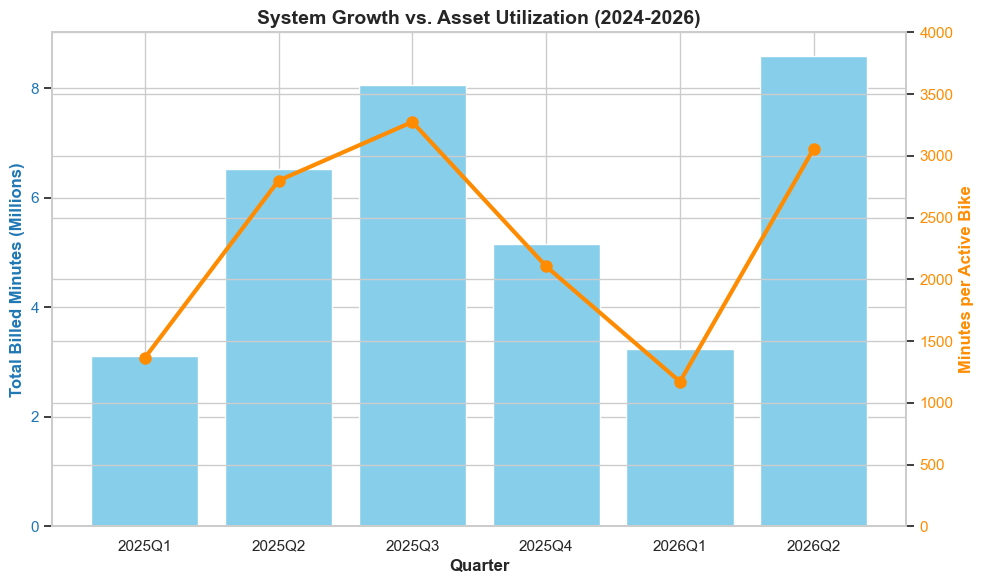

In [14]:
# 4. Aggregate core metrics per quarter
growth_summary = (
    df.groupby('year_quarter')
    .agg(
        total_duration=('duration', 'sum'),
        total_trips=('trip_id', 'count'),
        active_bikes=('bike_id', 'nunique')
    )
    .reset_index()
)

# 5. Calculate Year-over-Year (YoY) growth (comparing Q2 2026 to Q2 2025, etc.)
growth_summary['duration_yoy_growth_%'] = growth_summary['total_duration'].pct_change(4) * 100
growth_summary['trips_yoy_growth_%'] = growth_summary['total_trips'].pct_change(4) * 100

# 6. Calculate Utilization (Are bikes being used more or just sitting there?)
growth_summary['minutes_per_bike'] = growth_summary['total_duration'] / growth_summary['active_bikes']

# 7. Print the results
print("\n--- QUARTERLY GROWTH & UTILIZATION SUMMARY ---")
# Drop the first 4 quarters since they won't have YoY data
print(growth_summary.dropna().to_string(index=False))

# Visualize Growth vs. Utilization for the executive presentation
fig1, ax1 = plt.subplots(figsize=(10, 6))

# Create a clean dataframe for plotting
plot_data = growth_summary.dropna()

# Primary Axis: Bar chart showing Total Duration Growth
ax1.bar(plot_data['year_quarter'].astype(str), 
        plot_data['total_duration'] / 1000000, 
        color='skyblue', label='Total Billed Minutes (Millions)')
ax1.set_xlabel('Quarter', fontweight='bold')
ax1.set_ylabel('Total Billed Minutes (Millions)', color='tab:blue', fontweight='bold')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Secondary Axis: Line chart showing flat Minutes per Bike (Utilization)
ax2 = ax1.twinx()
ax2.plot(plot_data['year_quarter'].astype(str), 
         plot_data['minutes_per_bike'], 
         color='darkorange', marker='o', linewidth=3, markersize=8, 
         label='Utilization (Minutes per Active Bike)')
ax2.set_ylabel('Minutes per Active Bike', color='darkorange', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim(0, 4000)

plt.title('System Growth vs. Asset Utilization (2024-2026)', fontsize=14, fontweight='bold')
fig1.tight_layout()
plt.show()


In [15]:
print("\n--- STRATEGIC ANALYSIS: E-BIKES VS STANDARD ---")

# Separate the durations by bike type, dropping any missing values
ebike_durations = df[df['bike_type'] == 'electric']['duration'].dropna()
standard_durations = df[df['bike_type'] == 'standard']['duration'].dropna()

# Run Welch's T-Test (equal_var=False) for right-skewed, unequal variance data
t_stat, p_val = stats.ttest_ind(
    ebike_durations, 
    standard_durations, 
    equal_var=False, 
    alternative='greater' # Testing if e-bike duration is strictly greater
)

print(f"E-bike Average Duration: {ebike_durations.mean():.2f} minutes")
print(f"Standard Bike Average Duration: {standard_durations.mean():.2f} minutes")
print(f"Welch's T-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_val:.4e}")

print("\n--- CONFIDENCE INTERVAL FOR MEAN DIFFERENCE ---")
# Calculate the 95% Confidence Interval for the difference in means (Standard - Ebike)
cm = sms.CompareMeans(sms.DescrStatsW(standard_durations), sms.DescrStatsW(ebike_durations))
lower_bound, upper_bound = cm.tconfint_diff(alpha=0.05, usevar='unequal')

print(f"95% Confidence Interval: Standard bikes generate between {lower_bound:.2f} and {upper_bound:.2f} MORE minutes per trip than E-bikes.")



--- STRATEGIC ANALYSIS: E-BIKES VS STANDARD ---
E-bike Average Duration: 16.06 minutes
Standard Bike Average Duration: 17.55 minutes
Welch's T-Statistic: -26.86
P-Value: 1.0000e+00

--- CONFIDENCE INTERVAL FOR MEAN DIFFERENCE ---
95% Confidence Interval: Standard bikes generate between 1.38 and 1.59 MORE minutes per trip than E-bikes.



--- STRATEGIC ANALYSIS: ONE-WAY ANOVA BY PASSHOLDER TYPE ---
Walk-up Mean Duration: 35.98 min
Indego30 Mean Duration: 15.65 min
Indego365 Mean Duration: 12.15 min
ANOVA F-Statistic: 19639.48
ANOVA P-Value: 0.0000e+00


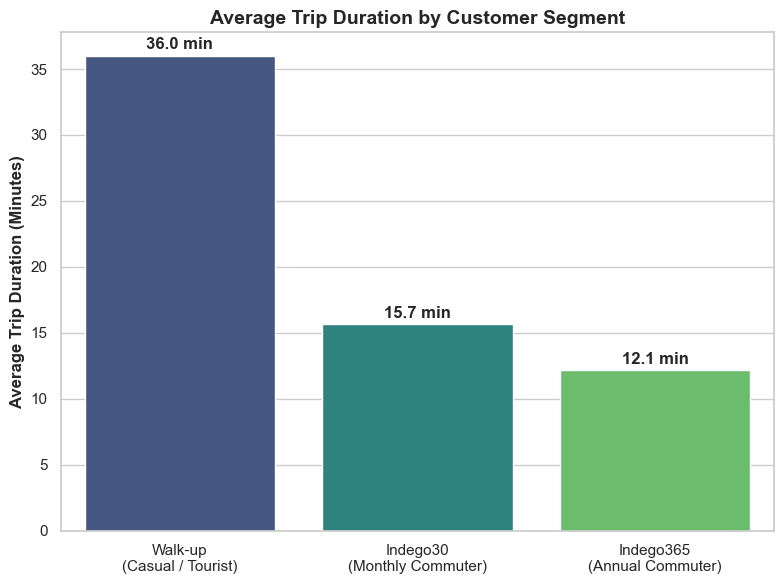

In [16]:
print("\n--- STRATEGIC ANALYSIS: ONE-WAY ANOVA BY PASSHOLDER TYPE ---")

# 1. Replace any infinite values with NaN, then drop all NaNs
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['passholder_type', 'duration'])

# 2. Extract the groups and explicitly convert them to 64-bit floats to prevent overflow
walk_up = df_clean[df_clean['passholder_type'] == 'Walk-up']['duration'].astype('float64')
indego30 = df_clean[df_clean['passholder_type'] == 'Indego30']['duration'].astype('float64')
indego365 = df_clean[df_clean['passholder_type'] == 'Indego365']['duration'].astype('float64')

# F-test to determine if duration variances across pass types are statistically significant
f_stat, p_val_anova = stats.f_oneway(walk_up, indego30, indego365)

print(f"Walk-up Mean Duration: {walk_up.mean():.2f} min")
print(f"Indego30 Mean Duration: {indego30.mean():.2f} min")
print(f"Indego365 Mean Duration: {indego365.mean():.2f} min")
print(f"ANOVA F-Statistic: {f_stat:.2f}")
print(f"ANOVA P-Value: {p_val_anova:.4e}")

# Visualize the ANOVA results to show the massive difference in customer segments
fig2, ax = plt.subplots(figsize=(8, 6))

# Data from our ANOVA test
pass_means = [walk_up.mean(), indego30.mean(), indego365.mean()]
pass_labels = ['Walk-up\n(Casual / Tourist)', 'Indego30\n(Monthly Commuter)', 'Indego365\n(Annual Commuter)']

# Create a bar plot using Seaborn
bars = sns.barplot(x=pass_labels, y=pass_means, hue=pass_labels, palette='viridis', legend=False, ax=ax)
ax.set_ylabel('Average Trip Duration (Minutes)', fontweight='bold')
ax.set_title('Average Trip Duration by Customer Segment', fontsize=14, fontweight='bold')

# Add the exact minute values on top of each bar for executive clarity
for i, v in enumerate(pass_means):
    ax.text(i, v + 0.5, f"{v:.1f} min", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()